In [ ]:
import gc
import pathlib
import random
from typing import Dict, List, Sequence, Tuple, Union
import uuid

In [ ]:
try:
    import cupy as cp
except ImportError:
    import warnings

    warnings.warn(
        "cupy import failed; falling back to numpy "
        "(GPU engine unavailable)",
        stacklevel=2,
    )
    import numpy as cp

# workaround: iplotx 1.7.x uses importlib.metadata without importing it
import importlib.metadata  # noqa: F401

import downstream.dstream as dstream
import hstrat
import marimo as mo
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator
import numpy as np
import pandas as pd
from phyloframe import legacy as pfl
import polars as pl
import seaborn as sns
from teeplot import teeplot as tp
from tqdm.auto import tqdm
from watermark import watermark

from pylib import draw_scatter_tree

/usr/local/lib/python3.10/dist-packages/marimo/_runtime/executor.py:138: UserWarning: cupy import failed; falling back to numpy (GPU engine unavailable)
  exec(cell.body, glbls)


In [ ]:
mo.md(
    f"""
```Text
{watermark(
    current_date=True,
    iso8601=True,
    machine=True,
    updated=True,
    python=True,
    iversions=True,
    globals_=globals(),
)}
```
"""
)

```Text
Last updated: 2026-05-01T02:31:30.972221+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

seaborn   : 0.13.2
pandas    : 2.2.3
numpy     : 2.1.2
phyloframe: 0.8.1
teeplot   : 1.4.2
hstrat    : 1.25.0
matplotlib: 3.10.7
downstream: 1.22.0
marimo    : 0.23.2
polars    : 1.40.1

```

In [ ]:
# Marimo CLI args (set via `marimo edit notebook.py -- --pop-size N ...`
# or `marimo export ipynb ... -- --pop-size N ...`). Defaults match the
# current sweep settings: POP_SIZE=200_000 hosts and N_STEPS=100 steps.
_args = mo.cli_args()
POP_SIZE = int(_args.get("pop-size") or 200_000)
N_STEPS = int(_args.get("n-steps") or 100)
N_REPLICATES = int(_args.get("n-replicates") or 1)
ENGINE = str(_args.get("engine") or "numpy").lower()
if ENGINE not in ("numpy", "cupy"):
    raise ValueError(
        f"engine must be 'numpy' or 'cupy', got {ENGINE!r}",
    )
SKIP_PLOTTING = bool(_args.get("skip-plotting") or False)
print(
    f"args: POP_SIZE={POP_SIZE} N_STEPS={N_STEPS} "
    f"N_REPLICATES={N_REPLICATES} ENGINE={ENGINE} "
    f"SKIP_PLOTTING={SKIP_PLOTTING}",
)

args: POP_SIZE=200000 N_STEPS=100 N_REPLICATES=1 ENGINE=numpy SKIP_PLOTTING=False


In [ ]:
use_cupy = (
    ENGINE == "cupy"
)  # use cupy backend (GPU), otherwise numpy (CPU)
xp = [np, cp][use_cupy]

## Simulation Implementation

This notebook is the wide-genome variant of
`2026-04-28-allele-abm-phylogeny-hstrat.py`: pathogen genomes are widened
so up to `N_SITES=64` allele loci can be tracked (the genome dtype is
chosen automatically — `uint16`/`uint32`/`uint64` for `N_SITES <=
16`/`32`/`64`), and the phylogeny sweep loops over all three bit-widths
so the resulting reconstructions can be compared side by side.
Population size, simulation length, replicate count, and array engine
(`numpy`/`cupy`) are all passed in as marimo CLI args (see the
`configure_args` cell). Phylogeny estimation still uses
*hereditary stratigraphic surface* annotations (see
https://hstrat.rtfd.io). Each infected host carries a `dstream_S=64`-site,
64-bit "hybrid" surface that ingests one differentia per simulation step;
on transmission the donor surface state is copied to the recipient (the
ABM analogue of `CloneDescendant`). At the end of the run a single
sample of `N_SAMPLE` currently-extant infections is taken; their surface
buffers feed `surface_unpack_reconstruct` + `surface_postprocess_trie`
to produce the estimated phylogeny. Per-step prevalence is logged by
Hamming weight as a separate long-form dataframe (one row per
`(Step, hw)` with a `count` column) rather than by individual
strain, so the trajectory dataframe stays compact even at large
`N_SITES`.

The vectorized deposit pattern is adapted from
https://github.com/mmore500/hstrat-synthesis (see `pylib/track_ca.py`).

In [ ]:
def simulate(
    N_SITES: int = 2,
    POP_SIZE: int = 1_000_000,
    CONTACT_RATE: float = 0.3,
    RECOVERY_RATE: float = 0.1,
    MUTATION_RATE: Union[float, Sequence[float]] = 1e-4,
    WANING_RATE: float = 0.02,
    IMMUNE_STRENGTH: float = 0.9,
    N_STEPS: int = 1_000,
    SEED_COUNT: int = 10,
    within_host_b: float = 0.2,
    within_host_t: float = 25.0,
    seed: int = 1,
    MUTATOR_HOSTS_N: int = 0,
    MUTATOR_HOSTS_MX: float = 1.0,
    MUTATION_THRESHOLD: float = 0.0,
    IMMUNITY_CEILING: float = 1.0,
    IMMUNITY_FLOOR: float = 0.0,
    track_phylogeny: bool = False,
    DSTREAM_S: int = 64,
    DSTREAM_ALGO=None,
    N_SAMPLE: int = 2000,
) -> Union[
    Tuple[pd.DataFrame, pd.DataFrame],
    Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame],
]:
    random.seed(seed)
    np.random.seed(seed)
    xp.random.seed(seed)

    if DSTREAM_ALGO is None:
        DSTREAM_ALGO = dstream.hybrid_0_steady_1_tilted_2_algo

    MUTATION_RATE = xp.asarray(MUTATION_RATE, dtype=xp.float32)

    # Pick the smallest unsigned int dtype that holds `N_SITES` bits.
    # 16/32/64-site sweeps round-trip through uint16/uint32/uint64
    # without truncation; >64 would need a custom multi-word genome.
    if N_SITES > 64:
        raise NotImplementedError(
            "current data types support only up to 64 sites",
        )
    elif N_SITES > 32:
        genome_dtype = xp.uint64
    elif N_SITES > 16:
        genome_dtype = xp.uint32
    else:
        genome_dtype = xp.uint16

    # Vectorized hstrat surface state. Shape (POP_SIZE, S) uint64; each
    # row mirrors a `HereditaryStratigraphicSurface(stratum_differentia_
    # bit_width=64)` buffer. Initial random fill stands in for the S
    # "predeposit" strata that fill the buffer at construction time;
    # after `step_count` simulation steps the per-row dstream_T is
    # `step_count` (predeposit ranks live at `dstream_rank < dstream_S`
    # and are stripped by `surface_postprocess_trie(delete_trunk=True)`).
    # At the end of the run, `N_SAMPLE` extant infections are sampled
    # and their surface buffers passed through
    # `hstrat.dataframe.surface_unpack_reconstruct` for tree estimation.

    def initialize_pop() -> (
        Tuple[xp.ndarray, xp.ndarray, xp.ndarray, xp.ndarray]
    ):
        """Initialize population statuses, genomes, and immune history."""
        # `genome_dtype` is sized to fit `N_SITES` bits — `uint16` for
        # `N_SITES <= 16`, `uint32` up to 32, `uint64` up to 64.
        pathogen_genomes = xp.zeros(shape=POP_SIZE, dtype=genome_dtype)
        host_immunities = xp.full(
            shape=(POP_SIZE, 2 * N_SITES),
            fill_value=0.0,
            dtype=xp.float32,
        )
        host_statuses = xp.full(
            shape=POP_SIZE, fill_value=0, dtype=xp.uint8
        )
        # Random S-stratum fill mirrors the surface's predeposit phase;
        # uninfected slots are overwritten when a host gets infected.
        pathogen_markers = xp.random.randint(
            low=0,
            high=2**63,
            size=(POP_SIZE, DSTREAM_S),
            dtype=xp.int64,
        ).astype(xp.uint64)
        pathogen_markers |= (
            xp.random.randint(
                low=0, high=2, size=(POP_SIZE, DSTREAM_S), dtype=xp.uint64
            )
            << 63
        )
        return (
            host_statuses,
            pathogen_genomes,
            host_immunities,
            pathogen_markers,
        )

    def infect_initial(
        host_statuses: xp.ndarray,
        pathogen_genomes: xp.ndarray,
    ) -> Tuple[xp.ndarray, xp.ndarray]:
        """Seed the initial infection wave with the starting strain."""
        seeded_indices = xp.random.choice(
            POP_SIZE, size=SEED_COUNT, replace=False
        )
        host_statuses[seeded_indices] = 1
        pathogen_genomes[seeded_indices] = 0  # wildtype
        return host_statuses, pathogen_genomes

    def calc_infection_probabilities(
        host_immunities: xp.ndarray,
        pathogen_genomes: xp.ndarray,
    ) -> xp.ndarray:
        host_susceptibilities = xp.reshape(
            1.0 - (IMMUNE_STRENGTH * host_immunities),
            (POP_SIZE, 2 * N_SITES),
        )

        pathogen_bits = (
            pathogen_genomes[:, None] >> xp.arange(N_SITES, dtype=xp.uint8)
        ) & 1
        pathogen_alleles = (
            pathogen_bits[:, :, None] == xp.array([0, 1])
        ).reshape(-1, 2 * N_SITES)

        # active_susc = xp.where(
        #     pathogen_alleles, host_susceptibilities, 1.0
        # )
        # res = xp.prod(active_susc, axis=1)
        active_susc = xp.where(
            pathogen_alleles, host_susceptibilities, np.nan
        )
        res = (
            xp.nanmean(active_susc, axis=1)
            * xp.nanmax(active_susc, axis=1)
            * xp.nanmin(host_susceptibilities, axis=1)
        )
        assert res.shape == (POP_SIZE,)
        return res

    if MUTATION_RATE.size == 1:

        def calc_mutation_probabilities(
            host_immunities: xp.ndarray,
            pathogen_genomes: xp.ndarray,
        ) -> xp.ndarray:
            pathogen_bits = (
                pathogen_genomes[:, None]
                >> xp.arange(N_SITES, dtype=xp.uint8)
            ) & 1

            imm_reshaped = xp.reshape(host_immunities, (-1, N_SITES, 2))

            idx_curr = pathogen_bits[:, :, None]
            idx_opp = 1 - idx_curr

            imm_curr = xp.take_along_axis(
                imm_reshaped, idx_curr, axis=2
            ).squeeze(axis=2)
            imm_opp = xp.take_along_axis(
                imm_reshaped, idx_opp, axis=2
            ).squeeze(axis=2)

            host_immunity_deltas = imm_curr - imm_opp

            b_values = 1.0 + within_host_b * host_immunity_deltas
            b_values = xp.where(
                xp.abs(b_values - 1.0) < 1e-7, 1.000001, b_values
            )

            # \\frac{y}{x} = \\frac{m}{b-1} \\left( e^{(b-1)t} - 1 \\right)
            return (MUTATION_RATE / (b_values - 1.0)) * (
                xp.exp((b_values - 1.0) * within_host_t) - 1.0
            )

    else:

        def calc_mutation_probabilities(
            host_immunities: xp.ndarray,
            pathogen_genomes: xp.ndarray,
        ) -> xp.ndarray:
            n_infected = host_immunities.shape[0]
            return (
                xp.ones((n_infected, 1), dtype=MUTATION_RATE.dtype)
                * MUTATION_RATE
            )

    def update_waning(host_immunities: xp.ndarray) -> xp.ndarray:
        """Decay immunity levels over time."""
        host_immunities *= 1.0 - WANING_RATE
        host_immunities[host_immunities > 0] = xp.clip(
            host_immunities[host_immunities > 0],
            IMMUNITY_FLOOR,
            IMMUNITY_CEILING,
        )
        return host_immunities

    def update_recoveries(
        host_statuses: xp.ndarray,
        host_immunities: xp.ndarray,
        pathogen_genomes: xp.ndarray,
    ) -> Tuple[xp.ndarray, xp.ndarray]:
        """Recover infected individuals with probability RECOVERY_RATE."""
        # Each infected host recovers independently at rate RECOVERY_RATE,
        # regardless of how long they have been infected. This matches the
        # ODE's per-person recovery rate.
        recovered_mask = (host_statuses >= 1) * xp.random.rand(
            POP_SIZE
        ) > 1 - RECOVERY_RATE

        pathogen_bits = (
            pathogen_genomes[:, None] >> xp.arange(N_SITES, dtype=xp.uint8)
        ) & 1
        pathogen_alleles = (
            pathogen_bits[:, :, None] == xp.array([0, 1])
        ).reshape(-1, 2 * N_SITES)

        assert np.all(
            pathogen_alleles[recovered_mask].sum(axis=1) == N_SITES
        )

        host_immunities[
            pathogen_alleles.astype(bool) & recovered_mask[:, None]
        ] = 1.0

        host_statuses += (host_statuses > 0).astype(xp.uint8)
        host_statuses[recovered_mask] = 0

        return host_statuses, host_immunities

    def transmit_infection(
        host_statuses: xp.ndarray,
        pathogen_genomes: xp.ndarray,
        host_immunities: xp.ndarray,
        pathogen_markers: xp.ndarray,
    ) -> Tuple[xp.ndarray, xp.ndarray, xp.ndarray]:
        """Vectorized transmission based on allele-specific susceptibility."""
        contacts = xp.random.randint(
            low=0, high=POP_SIZE, size=POP_SIZE, dtype=xp.uint32
        )
        inf_probs = (
            calc_infection_probabilities(
                host_immunities, pathogen_genomes[contacts]
            )
            * (host_statuses == 0)
            * (host_statuses[contacts] > 0)
            * CONTACT_RATE
        )

        new_infections = xp.random.rand(POP_SIZE) < inf_probs
        host_statuses[new_infections] = 1
        pathogen_genomes[new_infections] = pathogen_genomes[contacts][
            new_infections
        ]
        if track_phylogeny:
            # Recipient inherits donor's surface state — vectorized
            # analogue of `HereditaryStratigraphicSurface.CloneDescendant`
            # without the post-clone deposit (the deposit happens later
            # in the step for all infected hosts uniformly).
            pathogen_markers[new_infections] = pathogen_markers[
                contacts[new_infections]
            ]

        return host_statuses, pathogen_genomes, pathogen_markers

    def apply_mutations(
        pathogen_genomes: xp.ndarray,
        host_statuses: xp.ndarray,
    ) -> xp.ndarray:
        """Apply mutations to newly infected individuals."""
        mutation_mask = (host_statuses == 1).astype(bool)

        mprobs = calc_mutation_probabilities(
            host_immunities[mutation_mask],
            pathogen_genomes[mutation_mask],
        )
        mutator_n = host_statuses[:MUTATOR_HOSTS_N].sum()
        mprobs[:mutator_n] = xp.minimum(
            mprobs[:mutator_n] * MUTATOR_HOSTS_MX, 1.0
        )

        mprobs[mprobs < MUTATION_THRESHOLD] = 0.0

        for s in range(N_SITES):
            mutation_occurs = (
                xp.random.rand(mprobs.shape[0]) < mprobs[:, s]
            ).astype(genome_dtype)
            pathogen_genomes[mutation_mask] ^= (
                mutation_occurs << s
            ).astype(genome_dtype)

        return pathogen_genomes

    def deposit_strata(
        host_statuses: xp.ndarray,
        pathogen_markers: xp.ndarray,
        t: int,
    ) -> xp.ndarray:
        """Deposit one stratum on every infected host's surface.

        The site is computed once per step from the global dstream_T
        (`t` here, where `t == 1` is the first real deposit on top of
        the random S-stratum init); a `None` site means the algorithm
        chose to retain the existing buffer this step.
        """
        site = DSTREAM_ALGO.assign_storage_site(DSTREAM_S, t)
        if site is None:
            return pathogen_markers
        infected_idx = xp.where(host_statuses > 0)[0]
        n_inf = int(infected_idx.size)
        if n_inf == 0:
            return pathogen_markers
        # uint64 random fill in two halves (numpy's randint maxes at int64)
        new_lo = xp.random.randint(
            0, 2**63, size=n_inf, dtype=xp.int64
        ).astype(xp.uint64)
        new_hi = xp.random.randint(0, 2, size=n_inf, dtype=xp.uint64) << 63
        pathogen_markers[infected_idx, site] = new_lo | new_hi
        return pathogen_markers

    def update_simulation(
        host_statuses: xp.ndarray,
        pathogen_genomes: xp.ndarray,
        host_immunities: xp.ndarray,
        pathogen_markers: xp.ndarray,
        t: int,
    ) -> Tuple[xp.ndarray, xp.ndarray, xp.ndarray, xp.ndarray]:
        """Run one step of the simulation."""
        (
            host_statuses,
            pathogen_genomes,
            pathogen_markers,
        ) = transmit_infection(
            host_statuses,
            pathogen_genomes,
            host_immunities,
            pathogen_markers,
        )
        pathogen_genomes = apply_mutations(pathogen_genomes, host_statuses)
        host_statuses, host_immunities = update_recoveries(
            host_statuses, host_immunities, pathogen_genomes
        )
        host_immunities = update_waning(host_immunities)
        if track_phylogeny:
            # Stratum deposit comes after recoveries so just-recovered
            # hosts (whose `host_statuses` is now 0) don't get a fresh
            # stratum — their surface state stops evolving once the
            # lineage dies out, which is the correct semantics.
            pathogen_markers = deposit_strata(
                host_statuses, pathogen_markers, t
            )

        return (
            host_statuses,
            pathogen_genomes,
            host_immunities,
            pathogen_markers,
        )

    (
        host_statuses,
        pathogen_genomes,
        host_immunities,
        pathogen_markers,
    ) = initialize_pop()
    host_statuses, pathogen_genomes = infect_initial(
        host_statuses, pathogen_genomes
    )
    data_log: List[Dict[str, float]] = []
    hw_log: List[Dict[str, float]] = []

    for t in tqdm(range(N_STEPS), mininterval=20.0):
        (
            host_statuses,
            pathogen_genomes,
            host_immunities,
            pathogen_markers,
        ) = update_simulation(
            host_statuses,
            pathogen_genomes,
            host_immunities,
            pathogen_markers,
            t + 1,
        )

        inf_mask = host_statuses > 0
        hw_prevalences: List[float] = [0.0] * (N_SITES + 1)

        if xp.any(inf_mask):
            infected_bits = (
                pathogen_genomes[inf_mask, None]
                >> xp.arange(N_SITES, dtype=xp.uint8)
            ) & 1
            hw_per_host = infected_bits.sum(axis=1).astype(xp.int64)
            hw_counts_arr = xp.bincount(hw_per_host, minlength=N_SITES + 1)
            hw_prevalences = [
                float(c) / POP_SIZE for c in hw_counts_arr.tolist()
            ]

        for w, count in enumerate(hw_prevalences):
            hw_log.append(
                {
                    "Step": t,
                    "Seed": seed,
                    "hw": w,
                    "count": count,
                }
            )

        avg_susc = xp.mean(
            1.0 - (IMMUNE_STRENGTH * host_immunities), axis=0
        )

        immunity_dict = {}
        for i in range(2 * N_SITES):
            site = i // 2
            bit = i % 2
            immunity_dict[f"Susc_S{site}_B{bit}"] = float(avg_susc[i])

        log_entry = {
            "Step": t,
            "Seed": seed,
            "Total_Infected": float(xp.sum(inf_mask)) / POP_SIZE,
        }
        log_entry.update(immunity_dict)
        data_log.append(log_entry)

    df = pd.DataFrame(data_log).fillna(0).copy()
    hw_df = pd.DataFrame(hw_log)
    if not track_phylogeny:
        return df, hw_df

    # Sample `N_SAMPLE` extant infections at the end of the run and
    # build the records dataframe expected by
    # `hstrat.dataframe.surface_unpack_reconstruct`. All sampled tips
    # share `dstream_T = N_STEPS` (one deposit per step) and are
    # marked extant; the implicit S predeposit strata sit at negative
    # ranks and get stripped by
    # `surface_postprocess_trie(delete_trunk=True)`.
    algo_name = f"dstream.{DSTREAM_ALGO.__name__}"
    S = DSTREAM_S
    T_bitwidth = 32
    bitwidth = 64
    bytes_per_T = T_bitwidth // 8  # 4
    bytes_per_storage = S * (bitwidth // 8)  # 64*8 = 512
    bytes_per_row = bytes_per_T + bytes_per_storage
    empty_records = pd.DataFrame(
        {
            "data_hex": pd.Series([], dtype=str),
            "dstream_algo": pd.Series([], dtype=str),
            "dstream_storage_bitoffset": pd.Series([], dtype="int64"),
            "dstream_storage_bitwidth": pd.Series([], dtype="int64"),
            "dstream_T_bitoffset": pd.Series([], dtype="int64"),
            "dstream_T_bitwidth": pd.Series([], dtype="int64"),
            "dstream_S": pd.Series([], dtype="int64"),
            "extant": pd.Series([], dtype=bool),
            "snapshot_step": pd.Series([], dtype="int64"),
            "genome": pd.Series([], dtype="int64"),
            "taxon_id": pd.Series([], dtype="int64"),
        },
    )
    infected_idx = xp.where(host_statuses > 0)[0]
    n_inf = int(infected_idx.size)
    # `surface_unpack_reconstruct` requires `dstream_T >= dstream_S`;
    # one deposit per step means we need at least `DSTREAM_S` steps
    # before the surface buffer leaves its predeposit phase.
    if n_inf == 0 or N_STEPS < DSTREAM_S:
        return df, hw_df, empty_records

    n_sample = min(N_SAMPLE, n_inf)
    sampled = (
        xp.random.choice(infected_idx, size=n_sample, replace=False)
        if n_sample < n_inf
        else infected_idx
    )
    # `cupy` arrays disallow implicit `np.asarray` conversion; copy to
    # host with `.get()` first when running on GPU.
    _to_np = (lambda a: np.asarray(a)) if xp is np else (lambda a: a.get())
    sampled_markers = _to_np(pathogen_markers[sampled])
    sampled_genomes = _to_np(pathogen_genomes[sampled])
    sampled_steps = np.full(n_sample, N_STEPS, dtype=np.uint32)
    sampled_taxon_ids = np.arange(n_sample, dtype=np.int64)

    # `np.uint32.astype(">u4")` is the big-endian encoding for the
    # `dstream_T` prefix; the storage hex follows per the layout
    # documented in `hstrat.serialization.surf_to_hex`.
    T_bytes_hex = sampled_steps.astype(">u4").tobytes()
    marker_bytes_hex = sampled_markers.astype(">u8").tobytes()
    data_hex = [
        (
            T_bytes_hex[i * bytes_per_T : (i + 1) * bytes_per_T]
            + marker_bytes_hex[
                i * bytes_per_storage : (i + 1) * bytes_per_storage
            ]
        ).hex()
        for i in range(n_sample)
    ]

    records_df = pd.DataFrame(
        {
            "data_hex": data_hex,
            "dstream_algo": algo_name,
            "dstream_storage_bitoffset": bytes_per_T * 8,
            "dstream_storage_bitwidth": bytes_per_storage * 8,
            "dstream_T_bitoffset": 0,
            "dstream_T_bitwidth": T_bitwidth,
            "dstream_S": S,
            "extant": True,
            "snapshot_step": sampled_steps.astype(np.int64),
            "genome": sampled_genomes.astype(np.int64),
            "taxon_id": sampled_taxon_ids,
        }
    )
    assert all(len(h) == bytes_per_row * 2 for h in data_hex), (
        f"hex length mismatch (expected {bytes_per_row * 2}, "
        f"got {set(len(h) for h in data_hex)})"
    )
    del data_hex, T_bytes_hex, marker_bytes_hex
    gc.collect()
    return df, hw_df, records_df

## Surface-Annotation Reconstruction

Given the snapshot records emitted by `simulate(..., track_phylogeny=
True)`, run `hstrat.dataframe.surface_unpack_reconstruct` followed by
`hstrat.dataframe.surface_postprocess_trie` to estimate the phylogenetic
tree. We use `AssignOriginTimeNodeRankTriePostprocessor(t0="dstream_S")`
so that origin times line up with simulation step numbers (the trunk
deposits at `dstream_rank < dstream_S` are deleted by default).

In [ ]:
def reconstruct_phylogeny(
    records_df: pd.DataFrame,
) -> pd.DataFrame:
    """Run surface_unpack_reconstruct + postprocess to get an alife df.

    The returned dataframe is in alife-standard format with extra
    ``snapshot_step`` / ``genome`` / ``extant`` columns forwarded from
    the input records. The `origin_time` column reports the simulation
    step at which each (estimated) lineage diverged.
    """
    in_df = pl.from_pandas(records_df)
    recon = hstrat.dataframe.surface_unpack_reconstruct(in_df)
    # The unpack frame is the largest intermediate (one row per
    # retained stratum across all sampled tips); free it before
    # `surface_postprocess_trie` allocates its own internal buffers.
    post = hstrat.dataframe.surface_postprocess_trie(
        recon,
        trie_postprocessor=(
            hstrat.phylogenetic_inference.AssignOriginTimeNodeRankTriePostprocessor(
                t0="dstream_S",
            )
        ),
    ).to_pandas()
    del recon, in_df
    gc.collect()
    # phyloframe's CSR builder fast path uses
    # `np.full(n, -1, dtype=ancestor_ids.dtype)`, which OverflowErrors
    # when `ancestor_id` is `pl.UInt64`; cast id columns to int64 here
    # so all downstream phyloframe pipelines (e.g. `alifestd_to_iplotx`,
    # `alifestd_downsample_tips_uniform_asexual`) work.
    for col in ("id", "ancestor_id"):
        if col in post.columns:
            post[col] = post[col].astype("int64")
    # `extant` defaults to NaN for inner nodes; cast to bool with NaN→False
    # so phyloframe predicate filters work cleanly.
    post["extant"] = post["extant"].fillna(False).astype(bool)
    # Inner nodes don't carry a snapshot/genome — coerce to numeric (NaN
    # for inner) so leaf-only `.astype(int)` calls in the plotter work.
    for col in ("snapshot_step", "genome", "origin_time"):
        if col in post.columns:
            post[col] = pd.to_numeric(post[col], errors="coerce")
    return post

## Surface-Reconstructed Phylogeny

Sweep `N_SITES` over a few values and render the surface-reconstructed
phylogeny next to the absolute-prevalence and Hamming-weight stackplots,
matching the layout of `2026-04-28-allele-abm-phylogeny.py`. Tips and the
stackplots share a per-strain `husl` palette.

In [ ]:
def make_phylogeny_plot(
    N_SITES: int,
    phylo_df,
    hw_df,
    phylogeny_df,
    max_tips: int = 10_000,
    seed: int = 0,
) -> None:
    # Mirror the exact-tracking notebook's pruning steps so the figures
    # are visually comparable: uniform tip downsampling + unifurcation
    # collapse + ladderize. Synthetic global root collapses multi-seed
    # origins to a single root (iplotx requirement).
    pruned_df = (
        pfl.alifestd_downsample_tips_uniform_asexual(
            phylogeny_df,
            n_downsample=max_tips,
            seed=0,
        )
        .pipe(pfl.alifestd_add_global_root)
        .pipe(pfl.alifestd_collapse_unifurcations)
        .pipe(pfl.alifestd_try_add_ancestor_list_col)
        .pipe(pfl.alifestd_ladderize_asexual)
        .pipe(pfl.alifestd_assign_contiguous_ids)
    )
    assert pfl.alifestd_validate(pruned_df)
    print(f"  downsampled tree: {len(pruned_df)} nodes")
    print(f"  leaf count: {pfl.alifestd_count_leaf_nodes(pruned_df)}")

    # Each leaf carries the snapshot pathogen `genome`; map it to a
    # Hamming weight so tips share the HW palette used by the
    # accompanying prevalence panels.
    pruned_df = pruned_df.assign(
        hw=pruned_df["genome"].map(
            lambda g: None if pd.isna(g) else bin(int(g)).count("1"),
        ),
    )
    pruned_df = pruned_df.assign(
        hw_label=pruned_df["hw"].map(
            lambda w: None if pd.isna(w) else f"HW {int(w)}"
        ),
    )

    hw_values = list(range(N_SITES + 1))
    hw_palette = sns.color_palette("rocket_r", len(hw_values))

    # `hw_df` is long form: one row per (Step, hw) with `count`
    # giving the per-step prevalence of infections at that Hamming
    # weight. Build a `hw_label` column for hue ordering and palette
    # lookup, and an inverted `y` for top-down plotting alongside the
    # tree.
    present_hw = sorted(int(w) for w in hw_df["hw"].unique())
    hw_labels = [f"HW {w}" for w in present_hw]
    plot_df = hw_df.assign(
        y=-hw_df["Step"],
        hw_label=hw_df["hw"].map(lambda w: f"HW {int(w)}"),
    )
    plot_df = plot_df[plot_df["count"] > 0]

    if len(present_hw) > 4:
        _idx = np.unique(
            np.linspace(0, len(present_hw) - 1, 4).round().astype(int)
        ).tolist()
    else:
        _idx = list(range(len(present_hw)))
    hw_legend_entries = [(present_hw[i], hw_labels[i]) for i in _idx]

    def _hw_handle(w, label):
        return plt.Line2D(
            [0],
            [0],
            marker="s",
            color="w",
            markerfacecolor=hw_palette[w],
            markersize=10,
            label=label,
        )

    hw_palette_map = {f"HW {w}": hw_palette[w] for w in present_hw}

    with tp.teed(
        plt.subplots,
        nrows=1,
        ncols=3,
        figsize=(8, 6),
        gridspec_kw={
            "width_ratios": [1.4, 1.0, 1.0],
            "wspace": 0.1,
        },
        sharey=True,
        teeplot_outattrs={
            "what": "phylogeny",
            "n_sites": N_SITES,
            "n_steps": int(phylo_df["Step"].max()) + 1,
            "replicate": seed,
            "method": "hstrat-surface",
        },
        teeplot_show=True,
        teeplot_subdir=pathlib.Path(__file__).stem,
    ) as (fig, axes):
        ax_tree, ax_strain, ax_hw = axes

        sns.histplot(
            data=plot_df,
            y="y",
            hue="hw_label",
            hue_order=hw_labels,
            weights="count",
            binwidth=phylo_df["Step"].diff().min(),
            multiple="stack",
            stat="count",
            element="poly",
            palette=hw_palette_map,
            ax=ax_strain,
            fill=True,
            linewidth=0,
            legend=False,
        )
        _band_xs = [
            c.get_paths()[0].vertices[:, 0].max()
            for c in ax_strain.collections
            if c.get_paths()
        ]
        if _band_xs:
            _peak = max(_band_xs)
            _lo, _ = ax_strain.get_xlim()
            ax_strain.set_xlim(_lo, _peak * 1.05)

        sns.kdeplot(
            data=plot_df,
            y="y",
            hue="hw_label",
            hue_order=hw_labels,
            weights="count",
            multiple="fill",
            common_norm=True,
            cut=0,
            palette=hw_palette_map,
            ax=ax_hw,
            fill=True,
            linewidth=0,
            legend=False,
            bw_adjust=0.5,
        )

        for ax in (ax_strain, ax_hw):
            ax.set_xlabel("")
        ax_hw.set_xlim(0, 1)

        ax_tree.set_ylabel("step")
        ax_tree.tick_params(left=True, labelleft=True)
        for ax in (ax_strain, ax_hw):
            ax.tick_params(labelleft=False, left=False)
            ax.xaxis.tick_top()
            ax.xaxis.set_label_position("top")

        ax_tree.tick_params(bottom=False, labelbottom=False)
        sns.despine(ax=ax_strain, left=True, bottom=True, top=False)
        sns.despine(ax=ax_hw, left=True, bottom=True, top=False)

        ax_hw.legend(
            handles=[
                _hw_handle(w, label) for w, label in hw_legend_entries
            ],
            title="Hamming weight",
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            frameon=False,
            handletextpad=0.4,
        )

        draw_scatter_tree(
            pruned_df.reset_index(drop=True),
            ax=ax_tree,
            hue="hw_label",
            scatter_kws=dict(
                legend=False,
                palette=hw_palette_map,
            ),
            tree_kws=dict(
                edge_color="gray",
                edge_linewidth=0.7,
                edge_zorder=1,
                ladderize=True,
            ),
        )
        sns.despine(ax=ax_tree, top=True, right=True, bottom=True)
        ax_tree.set_ylim(ax_hw.get_ylim())
        ax_tree.set_aspect("auto")
        ax_tree.yaxis.set_major_locator(MaxNLocator(integer=True))
        ax_tree.yaxis.set_major_formatter(
            FuncFormatter(lambda x, _: f"{abs(int(round(x)))}"),
        )

=== seed=1 N_SITES=16 uid=05303276c6ff4b78a5abacfc3062bffb ===


100%|██████████| 100/100 [00:28<00:00,  3.54it/s]


  snapshot rows: 200
  extant rows: 200


/usr/local/lib/python3.10/dist-packages/alifedata_phyloinformatics_convert/_impl/phytrack_Systematcs.py:7: UserWarning: ImportWarning: phylotrackpy.Systematics import failed; inserting a no-op mock for Systematics. This is likely because phylotrackpy is not installed.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/alifedata_phyloinformatics_convert/_impl/phytrack_Systematcs.py:7: UserWarning: ImportWarning: phylotrackpy.Systematics import failed; inserting a no-op mock for Systematics. This is likely because phylotrackpy is not installed.
  warnings.warn(
2026-05-01 02:32:05 INFO     - worker collecting slice(0, 1000000, None)
2026-05-01 02:32:05 INFO     - worker exploding slice(0, 1000000, None)
2026-05-01 02:32:05 INFO     enter log_context_duration for dstream.dataframe.explode_lookup_unpacked (slice(0, 1000000, None))
/usr/local/lib/python3.10/dist-packages/downstream/dataframe/_impl/_check_downstream_version.py:34: UserWarning: Dataframe downstream_version column not pr

  reconstructed: 400 nodes
  extant tips: 200
  downsampled tree: 203 nodes
  leaf count: 200
teeplots/2026-04-29-allele-abm-phylogeny-hstrat-32site/method=hstrat-surface+n_sites=16+n_steps=100+replicate=1+viz=subplots+what=phylogeny+ext=.pdf
teeplots/2026-04-29-allele-abm-phylogeny-hstrat-32site/method=hstrat-surface+n_sites=16+n_steps=100+replicate=1+viz=subplots+what=phylogeny+ext=.png


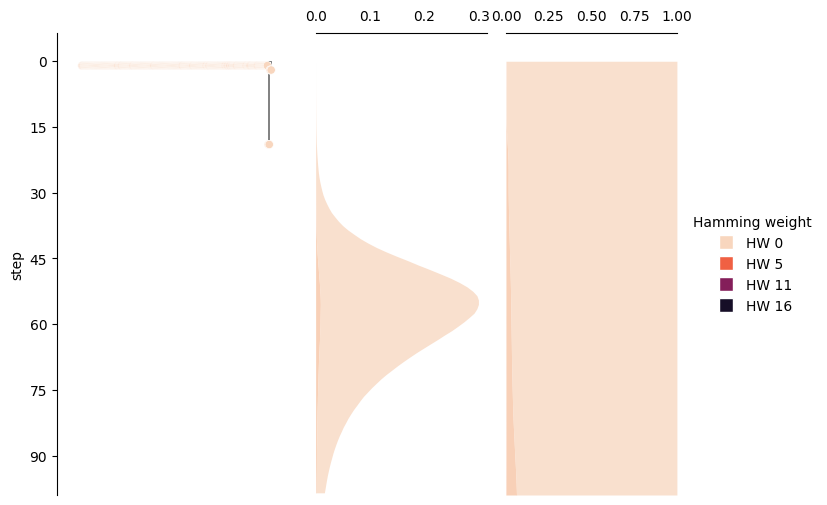

=== seed=1 N_SITES=32 uid=55d709a2857f40ed8ddd7fcb9a2b199f ===


100%|██████████| 100/100 [00:44<00:00,  2.27it/s]


  snapshot rows: 0
  (no infected hosts past S=64 — skipping plot)
=== seed=1 N_SITES=64 uid=72309a389e2a404f948a52cc1d6159f5 ===


100%|██████████| 100/100 [01:20<00:00,  1.25it/s]


  snapshot rows: 200
  extant rows: 200


/usr/local/lib/python3.10/dist-packages/alifedata_phyloinformatics_convert/_impl/phytrack_Systematcs.py:7: UserWarning: ImportWarning: phylotrackpy.Systematics import failed; inserting a no-op mock for Systematics. This is likely because phylotrackpy is not installed.
  warnings.warn(
2026-05-01 02:34:18 INFO     - worker collecting slice(0, 1000000, None)
2026-05-01 02:34:18 INFO     - worker exploding slice(0, 1000000, None)
2026-05-01 02:34:18 INFO     enter log_context_duration for dstream.dataframe.explode_lookup_unpacked (slice(0, 1000000, None))
/usr/local/lib/python3.10/dist-packages/downstream/dataframe/_impl/_check_downstream_version.py:34: UserWarning: Dataframe downstream_version column not provided
  warnings.warn(
2026-05-01 02:34:18 INFO     begin explode_lookup_unpacked
2026-05-01 02:34:18 INFO      - prepping data...
2026-05-01 02:34:18 INFO      - exploding dataframe...
2026-05-01 02:34:18 INFO      - unpacking hex strings...
2026-05-01 02:34:18 INFO      - looking up

  reconstructed: 400 nodes
  extant tips: 200
  downsampled tree: 202 nodes
  leaf count: 200
teeplots/2026-04-29-allele-abm-phylogeny-hstrat-32site/method=hstrat-surface+n_sites=64+n_steps=100+replicate=1+viz=subplots+what=phylogeny+ext=.pdf
teeplots/2026-04-29-allele-abm-phylogeny-hstrat-32site/method=hstrat-surface+n_sites=64+n_steps=100+replicate=1+viz=subplots+what=phylogeny+ext=.png


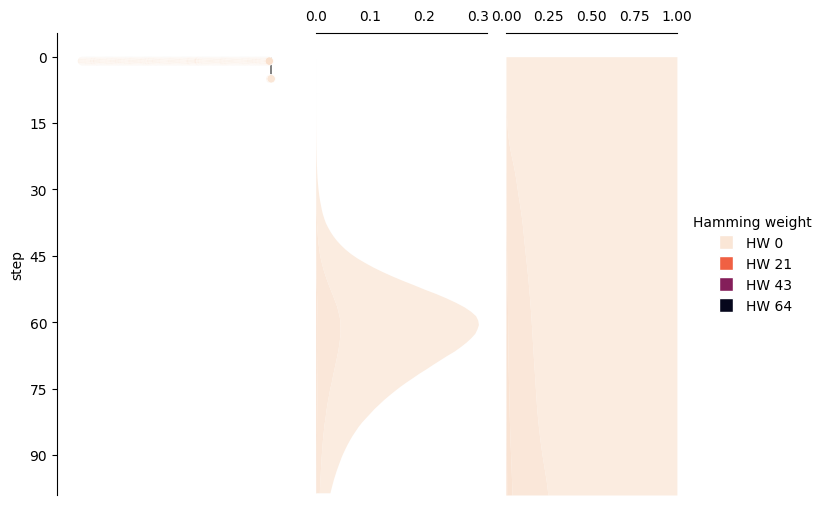

wrote trajectory parquet (300 rows): outdata/2026-04-29-allele-abm-phylogeny-hstrat-32site/a=traj+what=2026-04-29-allele-abm-phylogeny-hstrat-32site+ext=.pqt
wrote hw parquet (11500 rows): outdata/2026-04-29-allele-abm-phylogeny-hstrat-32site/a=hw+what=2026-04-29-allele-abm-phylogeny-hstrat-32site+ext=.pqt
wrote records parquet (400 rows): outdata/2026-04-29-allele-abm-phylogeny-hstrat-32site/a=records+what=2026-04-29-allele-abm-phylogeny-hstrat-32site+ext=.pqt
wrote phylogeny parquet (800 rows): outdata/2026-04-29-allele-abm-phylogeny-hstrat-32site/a=phylo+what=2026-04-29-allele-abm-phylogeny-hstrat-32site+ext=.pqt


In [ ]:
# Sweep over (16, 32, 64)-bit genomes × `N_REPLICATES` replicate seeds.
# Each replicate gets a fresh `replicate_uid`; the same uid is stamped
# onto rows in the trajectory, raw-records, and reconstructed-phylogeny
# parquets so joins across the three files are unambiguous.
# `N_SAMPLE` caps memory: it bounds the number of extant infections
# snapshotted at the end of the run that flow into
# `surface_unpack_reconstruct` (each row is ~1 KB of hex). Use the
# canonical 64-bit hybrid algo, `dstream.hybrid_0_steady_1_tilted_2_algo`.
PHYLO_MUTATION_RATE = 1e-5

nbname = pathlib.Path(__file__).stem
out_dir = pathlib.Path("outdata") / nbname
out_dir.mkdir(parents=True, exist_ok=True)

traj_chunks = []
hw_chunks = []
records_chunks = []
phylo_chunks = []

for _seed in range(1, N_REPLICATES + 1):
    for PHYLO_N_SITES in (16, 32, 64):
        replicate_uid = uuid.uuid4().hex
        print(
            f"=== seed={_seed} N_SITES={PHYLO_N_SITES} "
            f"uid={replicate_uid} ===",
        )
        _phylo_df, _hw_df, _records_df = simulate(
            MUTATION_RATE=PHYLO_MUTATION_RATE,
            N_SITES=PHYLO_N_SITES,
            N_STEPS=N_STEPS,
            POP_SIZE=POP_SIZE,
            CONTACT_RATE=0.35,
            RECOVERY_RATE=0.1,
            WANING_RATE=0.01,
            IMMUNE_STRENGTH=0.95,
            SEED_COUNT=2,
            IMMUNITY_FLOOR=0.05,
            IMMUNITY_CEILING=1.0,
            seed=_seed,
            track_phylogeny=True,
            N_SAMPLE=200,
        )
        print(f"  snapshot rows: {len(_records_df)}")

        # Stamp every row with the replicate's parameter key + uid so
        # the per-replicate trajectory, hw, records, and phylogeny
        # files can be split apart again downstream by filtering on
        # `replicate_uid`.
        _params = {
            "replicate_uid": replicate_uid,
            "seed": _seed,
            "n_sites": PHYLO_N_SITES,
            "pop_size": POP_SIZE,
            "n_steps": N_STEPS,
            "engine": ENGINE,
        }
        traj_chunks.append(_phylo_df.assign(**_params))
        hw_chunks.append(_hw_df.assign(**_params))
        # Save the *raw* surface records (the input to
        # `surface_unpack_reconstruct`) so reconstruction can be re-run
        # downstream without re-simulating. Empty records frames are
        # appended too — they preserve the (replicate_uid, params)
        # bookkeeping for replicates whose lineage died before
        # `dstream_S` deposits accumulated.
        records_chunks.append(_records_df.assign(**_params))

        if len(_records_df) == 0:
            print("  (no infected hosts past S=64 — skipping plot)")
            del _phylo_df, _hw_df, _records_df
            gc.collect()
            continue
        print(f"  extant rows: {int(_records_df['extant'].sum())}")
        _phylogeny_df = reconstruct_phylogeny(_records_df)
        # Free the records dataframe right after reconstruct — the hex
        # column is the biggest single buffer in the pipeline and isn't
        # needed once the alife df is built.
        del _records_df
        gc.collect()
        print(f"  reconstructed: {len(_phylogeny_df)} nodes")
        print(f"  extant tips: {int(_phylogeny_df['extant'].sum())}")

        phylo_chunks.append(_phylogeny_df.assign(**_params))

        if SKIP_PLOTTING:
            print("  (SKIP_PLOTTING=True — skipping plot)")
        else:
            make_phylogeny_plot(
                PHYLO_N_SITES,
                _phylo_df,
                _hw_df,
                _phylogeny_df,
                seed=_seed,
            )
        del _phylo_df, _hw_df, _phylogeny_df
        gc.collect()

# Concat-across-replicates → four parquet files (trajectory, hw,
# raw records, reconstructed phylogeny). `Susc_*` columns vary in
# cardinality across `N_SITES`, so missing columns auto-fill NaN on
# concat — that's expected.
traj_df_all = (
    pd.concat(traj_chunks, ignore_index=True)
    if traj_chunks
    else pd.DataFrame()
)
hw_df_all = (
    pd.concat(hw_chunks, ignore_index=True)
    if hw_chunks
    else pd.DataFrame()
)
records_df_all = (
    pd.concat(records_chunks, ignore_index=True)
    if records_chunks
    else pd.DataFrame()
)
phylo_df_all = (
    pd.concat(phylo_chunks, ignore_index=True)
    if phylo_chunks
    else pd.DataFrame()
)

traj_path = out_dir / f"a=traj+what={nbname}+ext=.pqt"
hw_path = out_dir / f"a=hw+what={nbname}+ext=.pqt"
records_path = out_dir / f"a=records+what={nbname}+ext=.pqt"
phylo_path = out_dir / f"a=phylo+what={nbname}+ext=.pqt"
traj_df_all.to_parquet(traj_path, index=False)
hw_df_all.to_parquet(hw_path, index=False)
records_df_all.to_parquet(records_path, index=False)
phylo_df_all.to_parquet(phylo_path, index=False)
print(f"wrote trajectory parquet ({len(traj_df_all)} rows): {traj_path}")
print(f"wrote hw parquet ({len(hw_df_all)} rows): {hw_path}")
print(
    f"wrote records parquet ({len(records_df_all)} rows): {records_path}"
)
print(f"wrote phylogeny parquet ({len(phylo_df_all)} rows): {phylo_path}")